[Chapter 12] Building Blocks of Deep Learning of Time Series

In [2]:
import numpy as np
np.random.seed(42)
import pandas as pd

import torch
import torch.nn as nn

import matplotlib.pyplot as plt

Feed-forward networks (FFN)

tensor([[-0.0037],
        [ 0.0079],
        [ 0.0084],
        [ 0.0213],
        [-0.0062],
        [-0.0126]], grad_fn=<AddmmBackward0>)

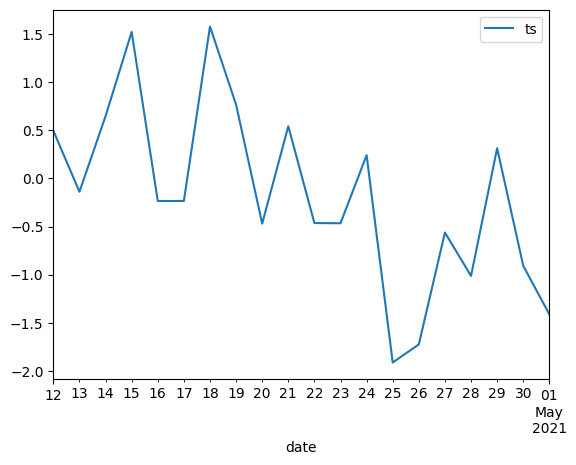

In [ ]:
# encoder-decoder paradigm
# input space (x) -> encoder -> latent space (z), encoded representation -> decoder -> prediction (y^, output we need)

# create a random walk
N = 20

df = pd.DataFrame({'date': pd.date_range(periods=N, start='2021-04-12', freq='D'),
                   'ts': np.random.randn(N)})

df.plot(x='date',y='ts')


# windowed input
ts = torch.from_numpy(df.ts.values).float()
# create windows of 15 over the dataset
window = 15
# input shape = batch size x input features = 6 x 15 (note: batch_size = 20 - 15 + 1 = 6)
ts_dataset = ts.unfold(0, size=window, step=1)


# define FFN (encoder as well as decoder)
# Sequential to stack different sub-components/multiple perceptrons(linear units + non-linear activations) together and use them with ease
ffn = nn.Sequential(
    # input layer
    nn.Linear(in_features=window, out_features=64), # (batch-size x window) --> (batch-size x 64)
    nn.ReLU(),
    # hidden layer
    nn.Linear(in_features=64, out_features=32), # (batch-size x 64) --> (batch-size x 32)
    nn.ReLU(),
    # hidden layer
    nn.Linear(in_features=32, out_features=32), # (batch-size x 32) --> (batch-size x 32)
    nn.ReLU(),
    # output layer
    nn.Linear(in_features=32, out_features=1), # (batch-size x 32) --> (batch-size x 1)
)

# use FFN
# ffn(ts_dataset)
ffn.forward(ts_dataset)

# output (batch-size x output units)
# FFNs are designed for non-temporal data, unable to handle variable-length sequences

recurrent neural networks (RNN) - vanilla RNN

In [ ]:
# designed to handle sequential data
# parameter sharing and recurrence from previous work 
#   (apply the same FFN at each time window but enhance with memory to store the relevant information for the task at hand)

# A_t = W*H_{t-1} + U*x_t + b_1 
# - tranform the input into a latent dimension
# - x_t: input at timestep t
# - W: learnable hidden-to-hidden weight matrix
# - U: learnable input-to-hidden weight matrix
# - b_1: learnable bias vector

# H_t = tanh(A_t)
# - use tanh activation to decide what info from the current timestep and pevious memory to keep and forget

# o_t = V*H_t + b_2
# - use new memory to generate an output
# - V: learnable hidden-to-output weight matrix
# - b_2: learnable bias vector

# RNN in PyTorch
rnn = nn.RNN(
    # number of expected features (if we use just the history of ts, it is 1)
    input_size=1, 
    # the dimension of hidden state, size of input-to-hidden and hidden-to-hidden matrices
    hidden_size=32,
    # number of RNNs that will be stacked on top of each other (default=1)
    num_layers=1,
    # tanh/relu (default is tanh)
    nonlinearity="tanh",
    # whether or not to add bias to the update equations, default=True
    bias=True,
    # batch_first = True: the expected input dimension as (batch size, sequence length, number of features)
    # batch_first = False: the expected input dimension as (sequence length, batch size, number of features)
    # the default is False
    batch_first=True,
    # dropout probability (popular regularization technique), default=0
    dropout=0,
    # enable a bidirectional RNN, default=False
    bidirectional=False
)

# add a dimension (feature size of 1) to the end because RNN expect input as a 3-d tensor
rnn_input = ts_dataset.unsqueeze(-1)
# since batch_first = True, [6, 15, 1] = (batch size, seq length, num of features)
print(rnn_input.shape)

output, hidden_states = rnn(rnn_input)

# (batch size, seq length, D*hidden layer) if batch_first=True
# (seq lenght, batch size, D*hidden layer) if batch_first=False
print(output.shape)
# (D*number of layers, batch size, hidden size) here D=1 (if bidirectional=False) and D=2 (if bidirectional=True)
print(hidden_states.shape)

# the hidden state tensor is equal to the last-output tensor (given output is just the affine transformation of the hidden state)
# hidden state is the latest hidden state
torch.equal(hidden_states[0], output[:,-1])

# flaw of RNN: BPTT (back propagation through time) 
#   means the # of units through which you need to backpropagate increase drastically with the length of sequence to be used for training
#   to backpropagate long graph, will encounter vanishing or exploding gradients
#   that's why vanilla RNNs are hardly used in practice

torch.Size([6, 15, 1])
torch.Size([6, 15, 32])
torch.Size([1, 6, 32])


True

RNN - long short-term memory (LSTM) networks

In [ ]:
# aim to resolve vanishing and exploding gradients in vanilla RNNs
# introduce memory cell (gradient highway, allow the gateways to pass relatively unhindered through a network) for long-term memory in addition to hidden-state memory of classical RNNs

# 3 gates in LSTM
# input gate: how much info to read from current input and previous hidden state 
# I_t = sigmoid(W_xi)*x_i + W_hi*H_{t-1} + b_i

# forget gate: how much info to forget from long-term memory
# F_t = sigmoid(W_xf)*x_i + W_hf*H_{t-1} + b_f

# output gate: how much of the current cell state should be used to create the curret hidden state (i.e. the output of the cell)
# O_t = sigmoid(W_xo)*x_i + W_ho*H_{t-1} + b_o

# long-term memory(cell state): 
# C_lt = tanh(W_xc*x_t + W_hc*H_{t-1} + b_c)

# use forget gate to decide how much info from previous timestep to carry forward
# use input gate to decide how much the current candidate cell state will be written into long-term memory 
# C_t = F_t (*) C_{t-1} + I_t (*) C_lt 
# (*) here is elementwise multiplication

# use the newly created current cell state and the output gate 
#   to decide ho wmuch info to pass on to the predicator through the current hidden state
# H_t = O_t * tanh(C_t)

# LSTM in PyTorch
lstm = nn.LSTM(
    input_size=1,
    hidden_size=32,
    num_layers=5,
    batch_first=True,
    dropout=0
)
output, (hidden_states, cell_states) = lstm(rnn_input)
print(output.shape)
print(hidden_states.shape)
print(cell_states.shape)

torch.Size([6, 15, 32])
torch.Size([5, 6, 32])
torch.Size([5, 6, 32])


RNN - gated recurrent unit (GRU)

In [ ]:
# simpler structure than LSTM (less gates, no cell state, less parameters, faster training)

# 2 gates in GRU

# reset gate: decide how much of the previous hidden state will be considered as candidate's hidden state of the current timestep
# R_t = sigmoid(W_xr * x_t + W_hr * H_{t-1} + b_r)

# update gate: how much of the previous hidden state should be carried forward 
#   and how much of the current cadidate's hidden state will be written into the hidden state
# U_t = sigmoid(W_xu * x_t + W_hu * H_{t-1} + b_u)

# H^_t = tanh(W_xh + W_hh*  R_t (*)H_{t-1} + b_h)
# H_t = U_t (*) H_{t-1} + (1-U_t) (*) H^_t

gru = nn.GRU(
    input_size=1,
    hidden_size=32,
    num_layers=5,
    batch_first=True,
    dropout=0
)

output, hidden_states = gru(rnn_input)
print(output.shape)
print(hidden_states.shape)


torch.Size([6, 15, 32])
torch.Size([5, 6, 32])


convolution neural networks (CNN)

In [ ]:
# typically 1D CNNs are used in time series forecasting

# kernel: 2D matrix with some value in it. kernel's size is smaller than image. we can "fit" the kernel inside the image.
#   2D input (4X4) (*) 1D kernel (2x2) = output (3x3)
#   1D input (1x4) (*) 1D kernel (1x2) = output (1x3)  -> e.g.: rolling means of sequence with a window of n （if kernel weights as 1/n) 

# 1D convolution can be thought of as a more powerful feature generator, where the features are learned from data
# with different weights on the kernels, we will extract different features

# output dimension (of a convolutional layer) = (L + p_l + p_r - d x (k-1) - 1)/s + 1 
# - L (input dimension), p_l (left padding size), p_r (right padding size), d (dilation), s (stride)
# - default case: p_l, p_r=0, s=1, d=1, O = L-(k-1) (e.g. as above, input = 4, k=2, o=(4+0+0-1-1)/1+1 = 3), by convolving the sequence, we reduce the sequence to L-(k-1)
# - padding: increase the size of the input, padding value depends on the problem (typically choose zero), L + p_l + p_r is effective length of sequence after padding
# -          for ts, typically pad on the left rather than the right because of the strong autocorrelation (to avoid the latest hidden state are directly influenced by padded values) 
# - receptive field: the region in the input space that influences the feature that's generated by the convolutional layers, for a single convolutional layer, it's mainly about kernal size
# - stride: move the kernal by stride size at a time, larger stride -> each layer look larger slice of history -> increase the receptive field
# - dilation: larger dilation (kernel will be dilated spatially, instead being applied on consecutive elements, elements in between will be skipped -> increase the receptive field of network)

# convolution in PyTorch
# input dim is (batch, channels (features, 1), seq), different with rnn (batch, seq, 1/feat)
cnn_input = ts_dataset.unsqueeze(1) # add dimension (1 as feature size) after first dimension (batch size)
cnn_input.shape
# kernel size
k = 3
# cnn
conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=k, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode="zeros")
# - in_channels: # of expected features in the input. if we just use the history of ts, it's 1
# - out_channels: # of kernels/filters applied to the input. each kernel produce a convolution operation with its own weight
# - kernel_size: size of kernel
# - stride: the stride of convolution, default=1
# - padding: padding added to both sides. default=0, "valid" is same as no padding, "same" pads the input so that input same with output dim
# - padding_mode: default=0 as all padded values as zeros. "replicate" like forward and backward fill. "reflect","circular" for more esoteric cases
# - dilation: default=1
# - groups: default=1, how many groups will be formed so that the convolutions happens within a group and not across
# - bias: default=True, whether add a learnable bias to the convolutions

output = conv(cnn_input)
assert output.size(-1) == cnn_input.size(-1) - k + 1
output.shape

torch.Size([6, 1, 13])